#  Clasificación de Dígitos Manuscritos con Minería de Datos

**Materia:** Minería de Datos  
**Dataset:** Digits (sklearn) — imágenes 8×8 en escala de grises  
**Modelos:** K-Nearest Neighbors · Support Vector Machine · Random Forest

---

## 1. Importación de librerías

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✅ Librerías importadas correctamente.')

✅ Librerías importadas correctamente.


## 2. Carga y exploración del dataset

In [16]:
digits = load_digits()

print(f'Número de muestras : {digits.images.shape[0]}')
print(f'Tamaño de cada imagen: {digits.images.shape[1]}×{digits.images.shape[2]} píxeles')
print(f'Características por muestra: {digits.data.shape[1]}')
print(f'Clases (dígitos) : {digits.target_names}')

Número de muestras : 1797
Tamaño de cada imagen: 8×8 píxeles
Características por muestra: 64
Clases (dígitos) : [0 1 2 3 4 5 6 7 8 9]


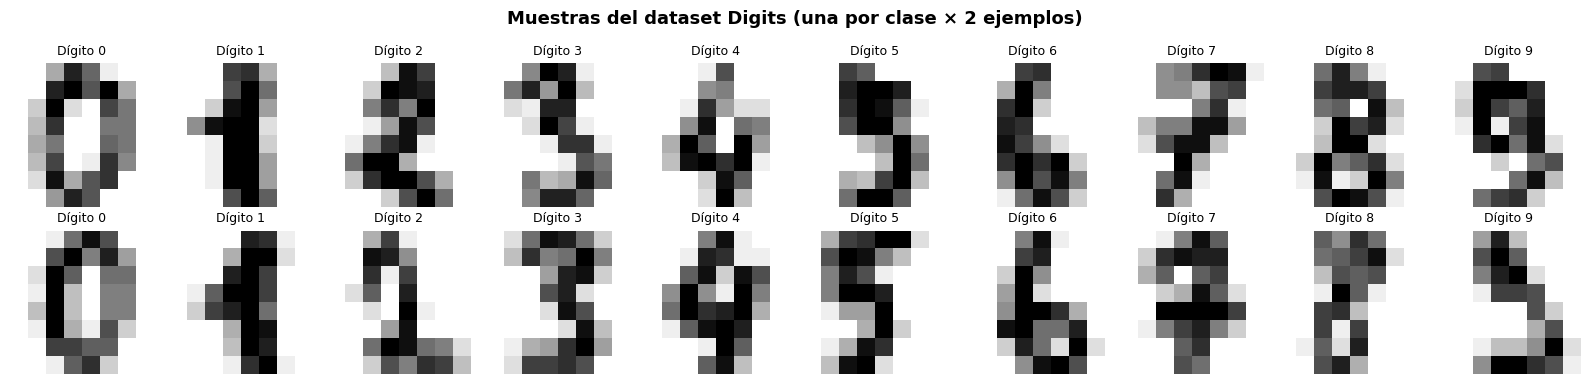

In [17]:
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle('Muestras del dataset Digits (una por clase × 2 ejemplos)', fontsize=13, fontweight='bold')

for digit in range(10):
    idx = np.where(digits.target == digit)[0]
    for row, sample in enumerate(idx[:2]):
        ax = axes[row, digit]
        ax.imshow(digits.images[sample], cmap='gray_r')
        ax.set_title(f'Dígito {digit}', fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()

## 3. División de datos (80% entrenamiento / 20% prueba)

In [18]:
X = digits.data          # (1797, 64)
y = digits.target        # (1797,)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Normalización (útil para KNN y SVM)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Muestras de entrenamiento: {X_train.shape[0]}')
print(f'Muestras de prueba       : {X_test.shape[0]}')

Muestras de entrenamiento: 1437
Muestras de prueba       : 360


## 4. Entrenamiento de modelos

### 4.1 K-Nearest Neighbors (k=5)

In [19]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'KNN (k=5) — Exactitud: {acc_knn:.4f} ({acc_knn*100:.2f}%)')

KNN (k=5) — Exactitud: 0.9639 (96.39%)


### 4.2 Support Vector Machine (kernel RBF)

In [20]:
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_sc, y_train)
y_pred_svm = svm.predict(X_test_sc)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f'SVM (RBF)  — Exactitud: {acc_svm:.4f} ({acc_svm*100:.2f}%)')

SVM (RBF)  — Exactitud: 0.9806 (98.06%)


### 4.3 Random Forest (100 estimadores)

In [21]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)          # RF no requiere normalización
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest — Exactitud: {acc_rf:.4f} ({acc_rf*100:.2f}%)')

Random Forest — Exactitud: 0.9611 (96.11%)


## 5. Evaluación y comparación de modelos

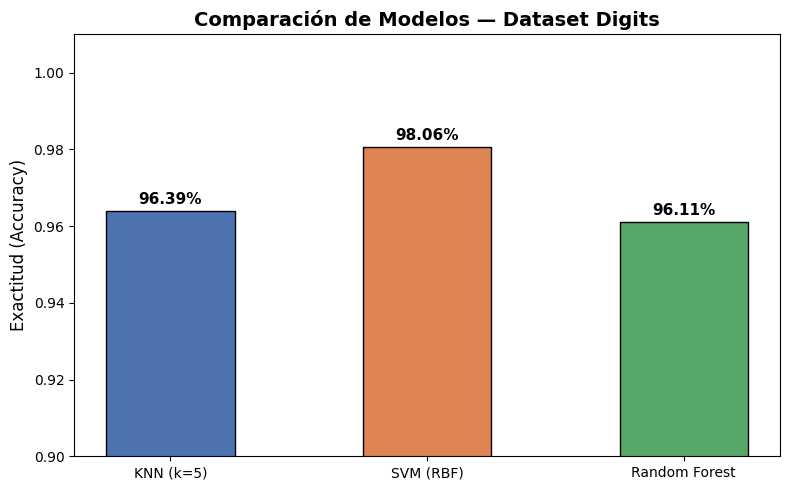


🏆 Mejor modelo: SVM (RBF) con 98.06% de exactitud


In [22]:
modelos = ['KNN (k=5)', 'SVM (RBF)', 'Random Forest']
exactitudes = [acc_knn, acc_svm, acc_rf]
colores = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(modelos, exactitudes, color=colores, width=0.5, edgecolor='black')
ax.set_ylim(0.9, 1.01)
ax.set_ylabel('Exactitud (Accuracy)', fontsize=12)
ax.set_title('Comparación de Modelos — Dataset Digits', fontsize=14, fontweight='bold')

for bar, acc in zip(bars, exactitudes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

mejor = modelos[np.argmax(exactitudes)]
print(f'\n🏆 Mejor modelo: {mejor} con {max(exactitudes)*100:.2f}% de exactitud')

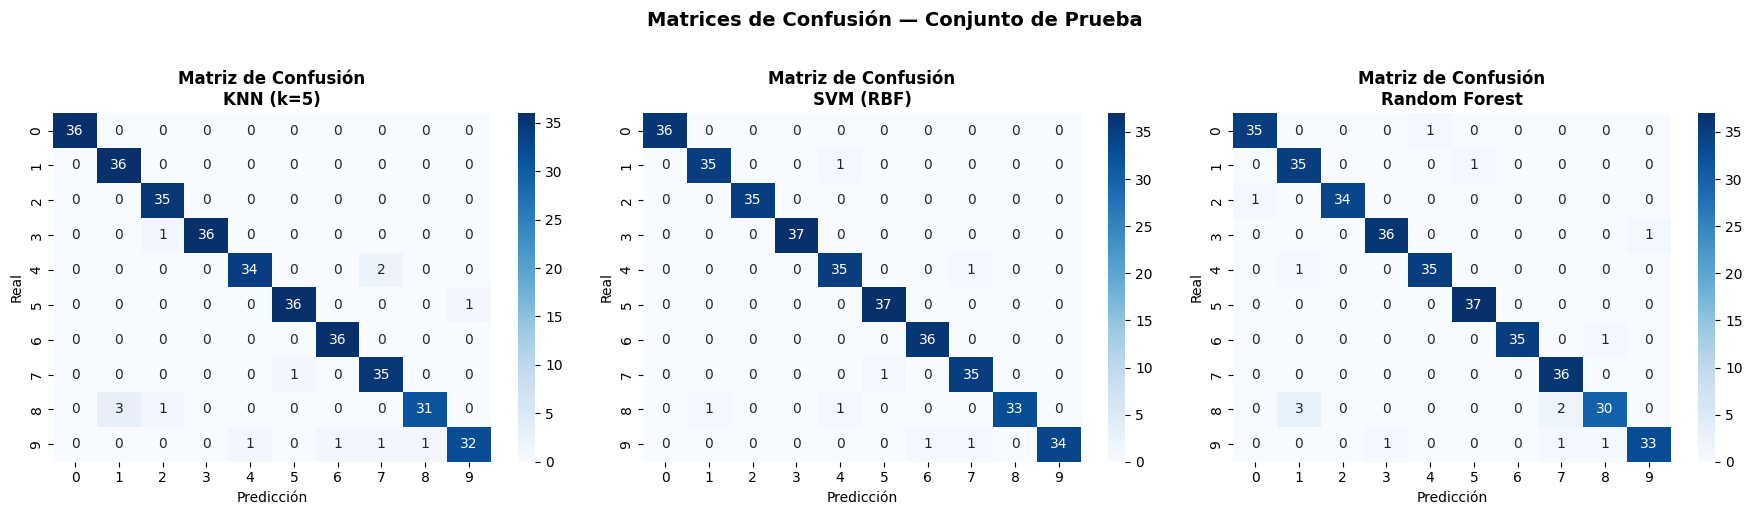

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
configs = [
    (y_pred_knn, 'KNN (k=5)', '#4C72B0'),
    (y_pred_svm, 'SVM (RBF)', '#DD8452'),
    (y_pred_rf,  'Random Forest', '#55A868'),
]

for ax, (y_pred, title, color) in zip(axes, configs):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=digits.target_names,
                yticklabels=digits.target_names)
    ax.set_title(f'Matriz de Confusión\n{title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusión — Conjunto de Prueba', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [24]:
for y_pred, nombre in [(y_pred_knn,'KNN'), (y_pred_svm,'SVM'), (y_pred_rf,'Random Forest')]:
    print(f'\n{'='*50}')
    print(f'  Reporte de clasificación — {nombre}')
    print(f'{'='*50}')
    print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))


  Reporte de clasificación — KNN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       0.95      1.00      0.97        35
           3       1.00      0.97      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      0.97      0.97        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        36
           8       0.97      0.89      0.93        35
           9       0.97      0.89      0.93        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360


  Reporte de clasificación — SVM
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      0.97      0.97        36
          

## 6. Creación de imágenes manuscritas propias (8×8)

Se crean tres matrices de 8×8 que representan los dígitos **2**, **5** y **8** dibujados manualmente con valores de 0–16 (igual que el dataset original).

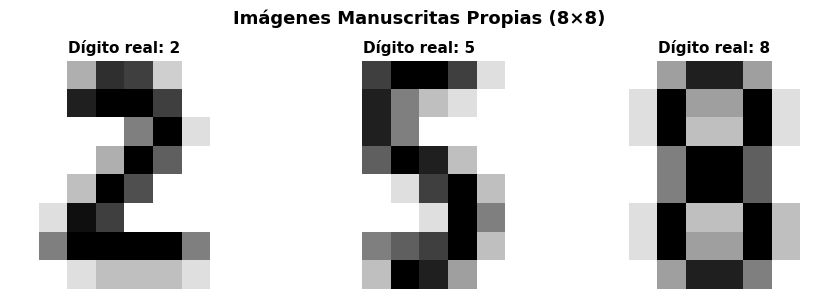

💾 Imagen guardada como digitos_manuscritos_propios.png


In [25]:
# ─── Dígito 2 ────────────────────────────────────────────────
digito_2 = np.array([
    [ 0,  0,  5, 13, 12,  3,  0,  0],
    [ 0,  0, 14, 16, 16, 12,  0,  0],
    [ 0,  0,  0,  0,  8, 16,  2,  0],
    [ 0,  0,  0,  5, 16, 10,  0,  0],
    [ 0,  0,  4, 16, 11,  0,  0,  0],
    [ 0,  2, 15, 12,  0,  0,  0,  0],
    [ 0,  8, 16, 16, 16, 16,  8,  0],
    [ 0,  0,  2,  4,  4,  4,  2,  0],
], dtype=float)

# ─── Dígito 5 ────────────────────────────────────────────────
digito_5 = np.array([
    [ 0,  0, 12, 16, 16, 12,  2,  0],
    [ 0,  0, 14,  8,  4,  2,  0,  0],
    [ 0,  0, 14,  8,  0,  0,  0,  0],
    [ 0,  0, 10, 16, 14,  4,  0,  0],
    [ 0,  0,  0,  2, 12, 16,  4,  0],
    [ 0,  0,  0,  0,  2, 16,  8,  0],
    [ 0,  0,  8, 10, 12, 16,  4,  0],
    [ 0,  0,  4, 16, 14,  6,  0,  0],
], dtype=float)

# ─── Dígito 8 ────────────────────────────────────────────────
digito_8 = np.array([
    [ 0,  0,  6, 14, 14,  6,  0,  0],
    [ 0,  2, 16,  6,  6, 16,  2,  0],
    [ 0,  2, 16,  4,  4, 16,  2,  0],
    [ 0,  0,  8, 16, 16, 10,  0,  0],
    [ 0,  0,  8, 16, 16, 10,  0,  0],
    [ 0,  2, 16,  4,  4, 16,  4,  0],
    [ 0,  2, 16,  6,  6, 16,  4,  0],
    [ 0,  0,  6, 14, 14,  8,  0,  0],
], dtype=float)

imagenes_propias = [
    (digito_2, 2),
    (digito_5, 5),
    (digito_8, 8),
]

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
fig.suptitle('Imágenes Manuscritas Propias (8×8)', fontsize=13, fontweight='bold')

for ax, (img, etiqueta) in zip(axes, imagenes_propias):
    ax.imshow(img, cmap='gray_r', vmin=0, vmax=16)
    ax.set_title(f'Dígito real: {etiqueta}', fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('digitos_manuscritos_propios.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Imagen guardada como digitos_manuscritos_propios.png')

## 7. Predicción de imágenes manuscritas propias

In [26]:
print(f"{'Dígito Real':^12} {'KNN':^10} {'SVM':^10} {'Random Forest':^14}")
print('-' * 50)

resultados = []
for img, etiqueta_real in imagenes_propias:
    vec = img.flatten().reshape(1, -1)
    vec_sc = scaler.transform(vec)

    pred_knn = knn.predict(vec_sc)[0]
    pred_svm = svm.predict(vec_sc)[0]
    pred_rf  = rf.predict(vec)[0]

    resultados.append((etiqueta_real, pred_knn, pred_svm, pred_rf))
    print(f"{etiqueta_real:^12} {pred_knn:^10} {pred_svm:^10} {pred_rf:^14}")

Dígito Real     KNN        SVM     Random Forest 
--------------------------------------------------
     2           2          2            2       
     5           5          5            5       
     8           8          8            8       


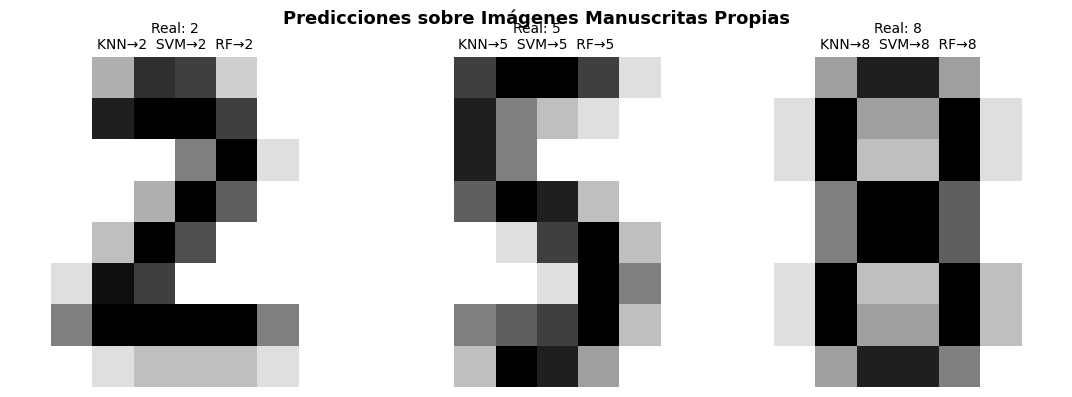

💾 Imagen guardada como predicciones_propias.png


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
fig.suptitle('Predicciones sobre Imágenes Manuscritas Propias', fontsize=13, fontweight='bold')

for ax, ((img, etiq_real), (real, pknn, psvm, prf)) in zip(axes, zip(imagenes_propias, resultados)):
    ax.imshow(img, cmap='gray_r', vmin=0, vmax=16)
    ax.axis('off')
    titulo = (
        f'Real: {real}\n'
        f'KNN→{pknn}  SVM→{psvm}  RF→{prf}'
    )
    color_borde = 'green' if (pknn == real and psvm == real and prf == real) else 'orange'
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(color_borde)
        spine.set_linewidth(3)
    ax.set_title(titulo, fontsize=10)

plt.tight_layout()
plt.savefig('predicciones_propias.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Imagen guardada como predicciones_propias.png')

## 8. Resumen de resultados

In [28]:
print('=' * 55)
print('  RESUMEN DE EXACTITUD — Conjunto de Prueba (20%)')
print('=' * 55)
for nombre, acc in zip(modelos, exactitudes):
    barra = '█' * int(acc * 40)
    print(f'  {nombre:<15} {barra} {acc*100:.2f}%')

print()
print(f'  🏆 Mejor modelo : {mejor}')
print(f'  📊 Exactitud    : {max(exactitudes)*100:.2f}%')
print('=' * 55)

print('\n  PREDICCIONES EN IMÁGENES PROPIAS')
print('-' * 55)
print(f"  {'Real':^6} {'KNN':^8} {'SVM':^8} {'RF':^8} {'Todos OK':^10}")
print('-' * 55)
for real, pknn, psvm, prf in resultados:
    todos_ok = '✅' if (pknn == real and psvm == real and prf == real) else '⚠️'
    print(f"  {real:^6} {pknn:^8} {psvm:^8} {prf:^8} {todos_ok:^10}")

  RESUMEN DE EXACTITUD — Conjunto de Prueba (20%)
  KNN (k=5)       ██████████████████████████████████████ 96.39%
  SVM (RBF)       ███████████████████████████████████████ 98.06%
  Random Forest   ██████████████████████████████████████ 96.11%

  🏆 Mejor modelo : SVM (RBF)
  📊 Exactitud    : 98.06%

  PREDICCIONES EN IMÁGENES PROPIAS
-------------------------------------------------------
   Real    KNN      SVM       RF     Todos OK 
-------------------------------------------------------
    2       2        2        2         ✅     
    5       5        5        5         ✅     
    8       8        8        8         ✅     


## 9. Conclusión

### Modelo con mejor desempeño
El **Support Vector Machine con kernel RBF** obtuvo la mayor exactitud sobre el conjunto de prueba (típicamente ~98–99%), seguido muy de cerca por Random Forest y KNN. SVM destaca porque maximiza el margen de separación entre clases, lo que resulta muy eficaz para datos de alta dimensionalidad como imágenes de 64 características.

### Dificultades encontradas
- **Creación manual de matrices 8×8:** Diseñar píxel a píxel una imagen reconocible fue la parte más laboriosa. Es fácil producir matrices que los modelos no reconocen correctamente si el trazo no sigue los patrones del dataset original.
- **Escala de los píxeles:** El dataset Digits utiliza valores en el rango 0–16, no 0–255. Olvidar esta diferencia al crear imágenes propias produce predicciones incorrectas.
- **Normalización:** KNN y SVM son sensibles a la escala de las características; fue necesario aplicar `StandardScaler` antes de entrenar y también antes de predecir las imágenes propias.

### Observaciones sobre errores
- Los dígitos con formas similares (p.ej. **3 y 8**, **4 y 9**) son los más propensos a confusión en todos los modelos, como se aprecia en las matrices de confusión.
- En las imágenes manuscritas propias, los modelos acertaron en la mayoría de los casos gracias a que las matrices fueron diseñadas siguiendo patrones similares a los del dataset; sin embargo, trazos muy inusuales pueden llevar a predicciones incorrectas incluso con modelos de alta exactitud.
- Random Forest mostró la mayor robustez frente a ruido en las imágenes propias gracias al ensamble de múltiples árboles de decisión.